In [ ]:
!pip install -U -q evaluate==0.4.3 transformers datasets>=2.14.5 accelerate>=0.27 2>/dev/null

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import gc
import numpy as np
import pandas as pd
import itertools
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score
)

from imblearn.over_sampling import RandomOverSampler
import accelerate
import evaluate
from datasets import Dataset, Image, ClassLabel
from transformers import (
    TrainingArguments,
    Trainer,
    ViTImageProcessor,
    ViTForImageClassification,
    DefaultDataCollator
)
import torch
from torch.utils.data import DataLoader
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomRotation,
    RandomResizedCrop,
    RandomHorizontalFlip,
    RandomAdjustSharpness,
    Resize,
    ToTensor
)

In [ ]:
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
image_dict = {}

from pathlib import Path
from tqdm import tqdm
import os
file_names = []
labels = []

df0 = pd.read_csv("/kaggle/input/ai-vs-human-generated-dataset/train.csv", index_col=0)

base_path = "/kaggle/input/ai-vs-human-generated-dataset/"
df0['image'] = base_path + df0['file_name']

df = df0[['image', 'label']]
print(df.shape)

df.head()

(79950, 2)


,image,label
0,/kaggle/input/ai-vs-human-generated-dataset/tr...,1
1,/kaggle/input/ai-vs-human-generated-dataset/tr...,0
2,/kaggle/input/ai-vs-human-generated-dataset/tr...,1
3,/kaggle/input/ai-vs-human-generated-dataset/tr...,0
4,/kaggle/input/ai-vs-human-generated-dataset/tr...,1


In [ ]:
df['label'].value_counts()

label
1    39975
0    39975
Name: count, dtype: int64

In [ ]:
dataset = Dataset.from_pandas(df).cast_column("image", Image())

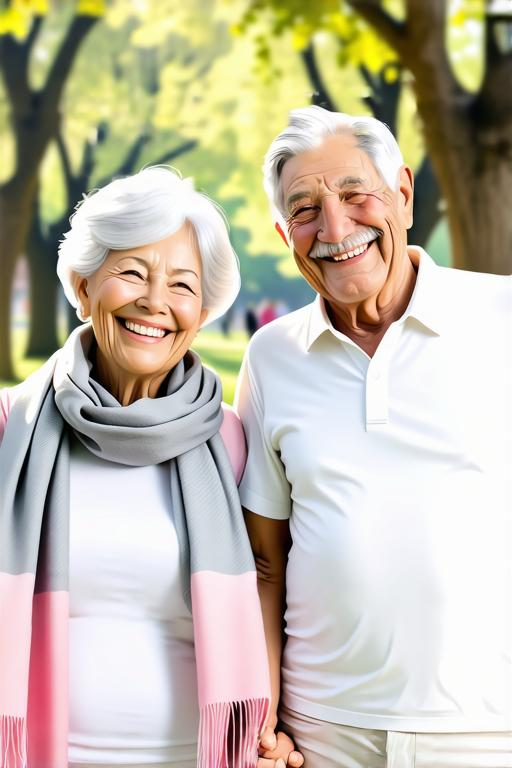

In [ ]:
dataset[0]["image"]

In [ ]:
labels_subset = labels[:5]
print(labels_subset)

[]


In [ ]:
labels_list = ['human', 'AI-generated']

label2id, id2label = dict(), dict()

for i, label in enumerate(labels_list):
    label2id[label] = i
    id2label[i] = label

print("Mapping of IDs to Labels:", id2label, '\n')
print("Mapping of Labels to IDs:", label2id)

Mapping of IDs to Labels: {0: 'human', 1: 'AI-generated'} 

Mapping of Labels to IDs: {'human': 0, 'AI-generated': 1}


In [ ]:
ClassLabels = ClassLabel(num_classes=len(labels_list), names=labels_list)

def map_label2id(example):
    example['label'] = ClassLabels.str2int(example['label'])
    return example

dataset = dataset.map(map_label2id, batched=True)
dataset = dataset.cast_column('label', ClassLabels)
dataset = dataset.train_test_split(test_size=0.1, shuffle=True, stratify_by_column="label")
train_data = dataset['train']
test_data = dataset['test']

Map:   0%|          | 0/79950 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/79950 [00:00<?, ? examples/s]

In [ ]:
model_str = 'google/vit-base-patch16-224-in21k'
processor = ViTImageProcessor.from_pretrained(model_str)
image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size["height"]
print("Size: ", size)
normalize = Normalize(mean=image_mean, std=image_std)

_train_transforms = Compose(
    [
        Resize((size, size)),
        RandomRotation(90),
        RandomAdjustSharpness(2),
        RandomHorizontalFlip(0.5),
        ToTensor(),
        normalize
    ]
)

_val_transforms = Compose(
    [
        Resize((size, size)),
        ToTensor(),
        normalize
    ]
)

def train_transforms(examples):
    examples['pixel_values'] = [_train_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

def val_transforms(examples):
    examples['pixel_values'] = [_val_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Size:  224


In [ ]:
train_data.set_transform(train_transforms)
test_data.set_transform(val_transforms)

In [ ]:
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example['label'] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
model = ViTForImageClassification.from_pretrained(model_str, num_labels=len(labels_list))

model.config.id2label = id2label
model.config.label2id = label2id

print(model.num_parameters(only_trainable=True) / 1e6)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.layernorm_before.weight          | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.weight | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.bias                | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.weight | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.weight   | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.den

85.800194


In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

In [ ]:
metric_name = "accuracy"

model_name = "ai_vs_human_generated_image_detection"

num_train_epochs = 5

args = TrainingArguments(
    output_dir=model_name,
    logging_dir='./logs',
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=8,
    num_train_epochs=num_train_epochs,
    weight_decay=0.02,
    warmup_steps=50,
    remove_unused_columns=False,
    save_strategy='epoch',
    load_best_model_at_end=True,
    save_total_limit=1,
    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_data,
    eval_dataset=test_data,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    processing_class=processor,
)

In [ ]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy
No log,0.689538,0,0.503189


{'eval_loss': 0.6895380020141602, 'eval_accuracy': 0.5031894934333959}

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.248247,0.328737,0.858036
2,0.221556,0.243917,0.900438
3,0.182334,0.231858,0.910819
4,0.168248,0.341639,0.867167
5,0.146773,0.211213,0.920200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=11245, training_loss=0.2081289098865989, metrics={'train_runtime': 10959.3083, 'train_samples_per_second': 32.828, 'train_steps_per_second': 1.026, 'total_flos': 2.7879680563589837e+19, 'train_loss': 0.2081289098865989, 'epoch': 5.0})

In [ ]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy
0.146773,0.211213,5,0.920200


{'eval_loss': 0.2112131267786026, 'eval_accuracy': 0.9202001250781738}

In [ ]:
outputs = trainer.predict(test_data)

print(outputs.metrics)

{'test_loss': 0.2112131267786026, 'test_model_preparation_time': 0.0038, 'test_accuracy': 0.9202001250781738, 'test_runtime': 104.7631, 'test_samples_per_second': 76.315, 'test_steps_per_second': 9.545}


Accuracy: 0.9202
F1 Score: 0.9199


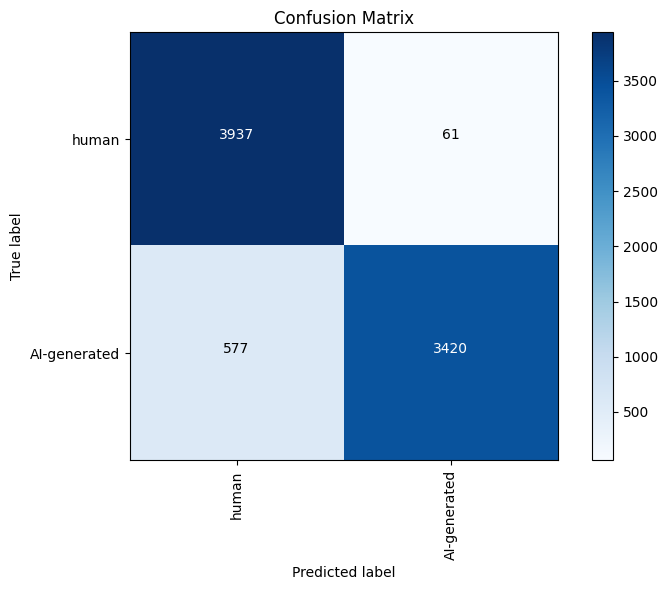


Classification report:

              precision    recall  f1-score   support

       human     0.8722    0.9847    0.9250      3998
AI-generated     0.9825    0.8556    0.9147      3997

    accuracy                         0.9202      7995
   macro avg     0.9273    0.9202    0.9199      7995
weighted avg     0.9273    0.9202    0.9199      7995



In [ ]:
y_true = outputs.label_ids

y_pred = outputs.predictions.argmax(1)

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues, figsize=(10, 8)):
    plt.figure(figsize=figsize)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = '.0f'
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    plt.tight_layout()
    plt.show()

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

if len(labels_list) <= 150:
    cm = confusion_matrix(y_true, y_pred)

    plot_confusion_matrix(cm, labels_list, figsize=(8, 6))

print()
print("Classification report:")
print()
print(classification_report(y_true, y_pred, target_names=labels_list, digits=4))

In [ ]:
trainer.save_model()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from transformers import pipeline

pipe = pipeline('image-classification', model=model_name, device=0)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

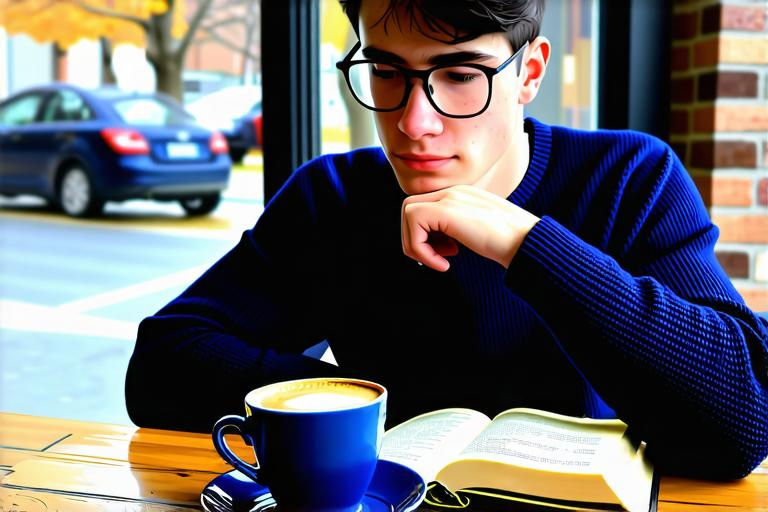

In [ ]:
image = test_data[1]["image"]

image

In [ ]:
pipe(image)

[{'label': 'AI-generated', 'score': 0.9961339235305786},
 {'label': 'human', 'score': 0.0038660713471472263}]

In [ ]:
id2label[test_data[1]["label"]]

'AI-generated'

In [ ]:
import os

export_directory = "my_vit_model"

print(f"Saving Model To Folder '{export_directory}'...")

trainer.model.save_pretrained(export_directory)

processor.save_pretrained(export_directory)

print("Export Success!")
print("Output: 'config.json', 'model.safetensors', dan 'preprocessor_config.json'.")

Saving Model To Folder 'my_vit_model'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Export Success!
Output: 'config.json', 'model.safetensors', dan 'preprocessor_config.json'.
